<a href="https://colab.research.google.com/github/ha22756/ha22756/blob/main/hanan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import numpy as np
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
from scipy.io import loadmat


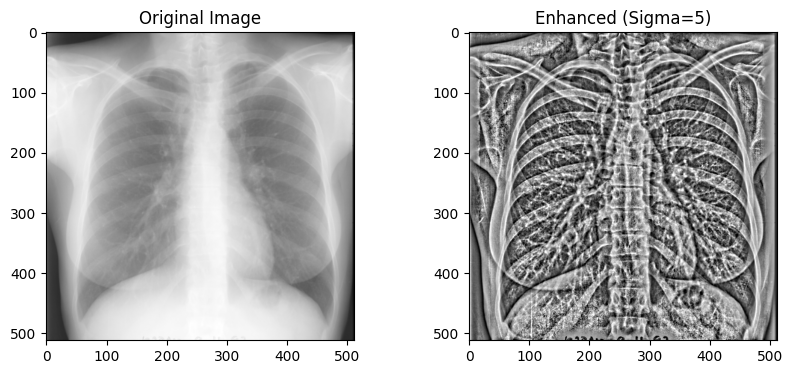

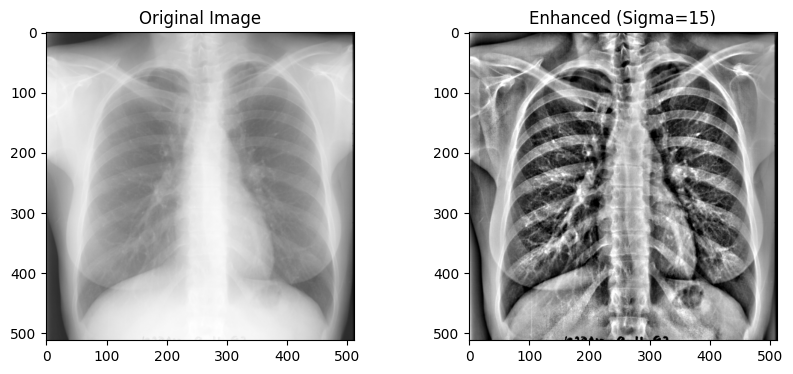

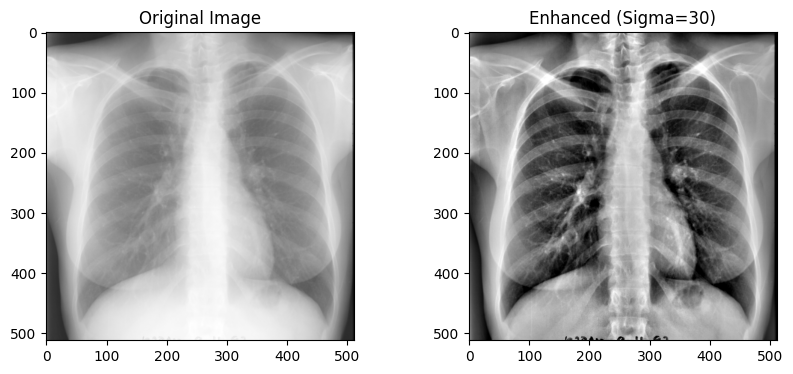

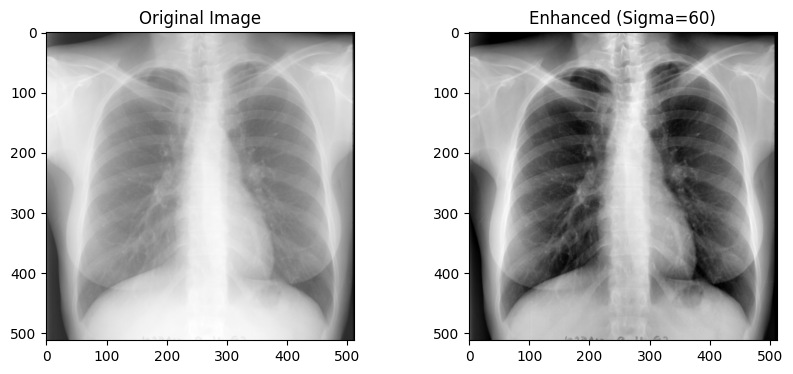

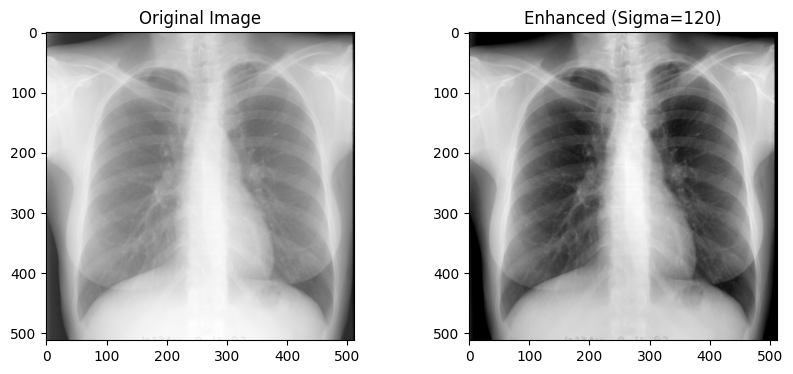


--- Summary of Metrics ---


,Sigma,Mean,Std Dev,Entropy
0,5,129.331676,57.483143,7.798147
1,15,130.594326,57.612123,7.780914
2,30,129.823952,58.611675,7.757603
3,60,129.376942,59.410235,7.688155
4,120,128.242519,60.122669,7.577519


In [9]:
import cv2
import numpy as np
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
from scipy.io import loadmat
from skimage.measure import shannon_entropy
import os
import pandas as pd # Import pandas for tabular display

# 1. تحميل ملف MAT من GitHub مباشرة
url = "https://github.com/ha22756/images/raw/refs/heads/main/JPCNN001_small.mat"
file_name = "JPCNN001_small.mat"

if not os.path.exists(file_name):
    print("Downloading image from GitHub...")
    os.system(f"wget {url} -O {file_name}")

# 2. استخراج الصورة
data = loadmat(file_name)
image = data['jrst']['cxr'][0][0]

def local_contrast(image, gauss_std=15):
    image = image.astype(np.float64)
    # المطلب 3: شرح الآلية (طرح المتوسط المحلي والقسمة على الانحراف المعياري)
    local_mean = gaussian_filter(image, sigma=gauss_std)
    low_pass = image - local_mean
    variance = gaussian_filter(low_pass ** 2, sigma=gauss_std)
    std_dev = np.sqrt(variance)

    std_dev[std_dev == 0] = np.mean(std_dev[std_dev != 0])

    # تحسين التباين
    enhanced_image = 64 * (low_pass / std_dev) + 127
    enhanced_image = np.clip(enhanced_image, 0, 255)
    return enhanced_image.astype(np.uint8)

# 3. اختبار 5 قيم مختلفة (المطلب 4) وحساب المقاييس (المطلب 7)
sigmas = [5, 15, 30, 60, 120]
all_metrics = [] # List to store metrics for all sigmas

# Define a dpi value for saving images; lower dpi means smaller file size.
# You can change this value (e.g., 50, 100, 200) to control image quality and size.
save_dpi = 75 # Example: 75 dpi for smaller images

for s in sigmas:
    enhanced = local_contrast(image, gauss_std=s)

    # حساب المقاييس المطلوبة
    m_val = np.mean(enhanced)
    s_val = np.std(enhanced)
    e_val = shannon_entropy(enhanced)

    # Store metrics in a dictionary and add to the list
    all_metrics.append({
        'Sigma': s,
        'Mean': m_val,
        'Std Dev': s_val,
        'Entropy': e_val
    })

    # عرض النتائج لكل تجربة (المطلب 5)
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.title(f"Original Image")
    plt.imshow(image, cmap='gray')
    plt.subplot(1, 2, 2)
    plt.title(f"Enhanced (Sigma={s})")
    plt.imshow(enhanced, cmap='gray')

    # Save the enhanced image with a specified dpi
    # The filename will be 'enhanced_sigma_X.png'
    output_filename = f"enhanced_sigma_{s}.png"
    plt.savefig(output_filename, dpi=save_dpi)

    plt.show()

# Display all metrics in a table
print("\n--- Summary of Metrics ---")
df_metrics = pd.DataFrame(all_metrics)
display(df_metrics)

Sigma      | Std Dev (Contrast)   | Entropy   
--------------------------------------------------
5          | 57.48                | 7.80      


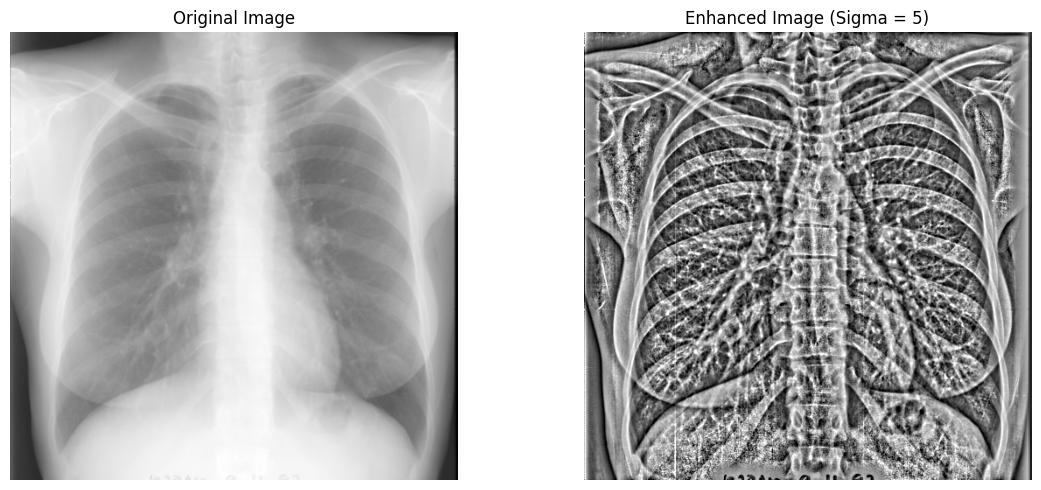

15         | 57.61                | 7.78      


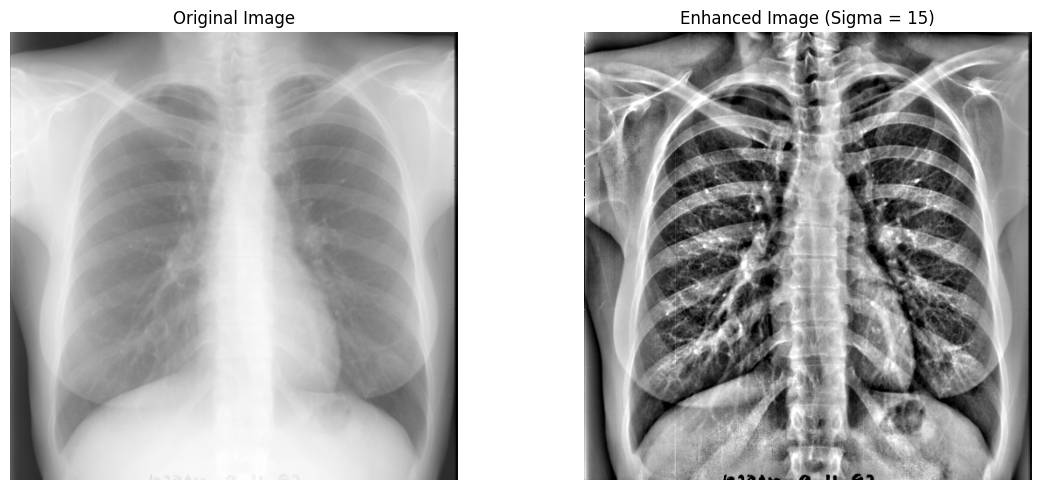

30         | 58.61                | 7.76      


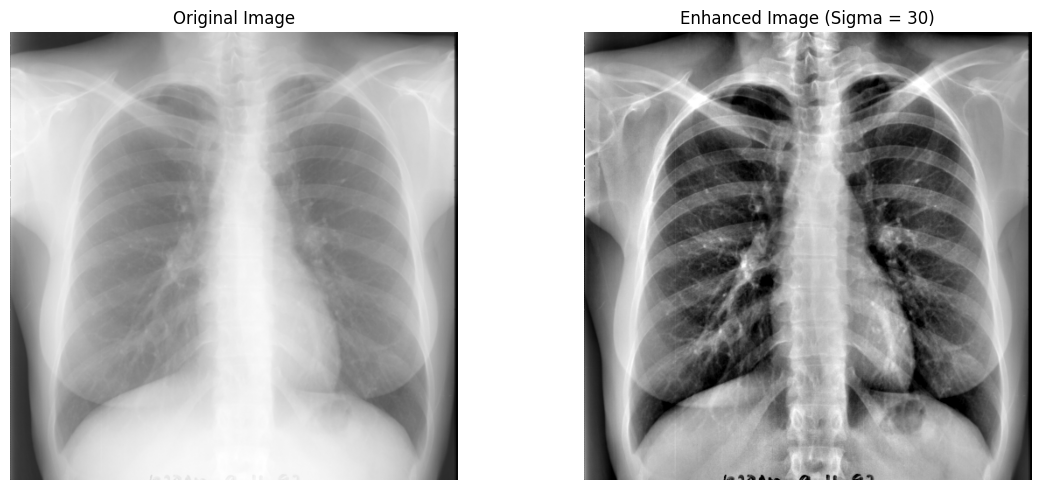

60         | 59.41                | 7.69      


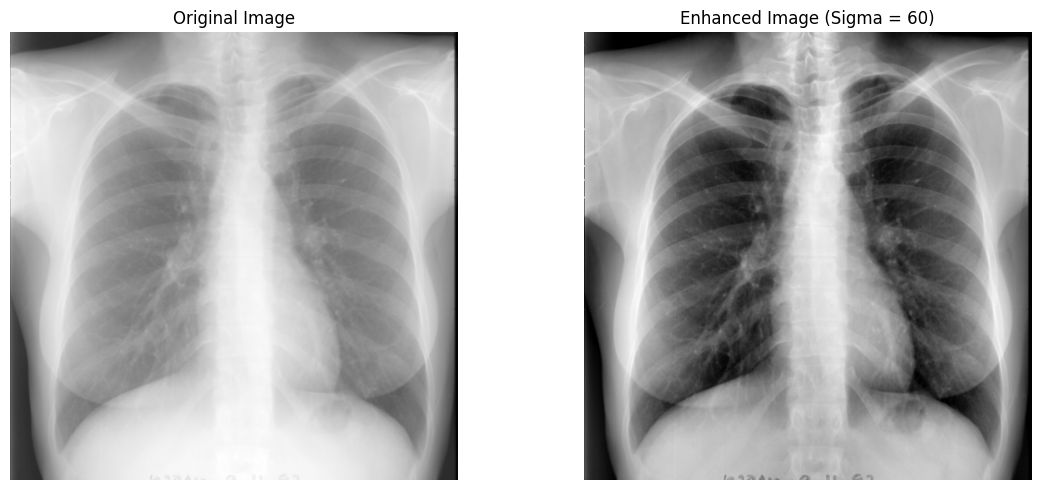

120        | 60.12                | 7.58      


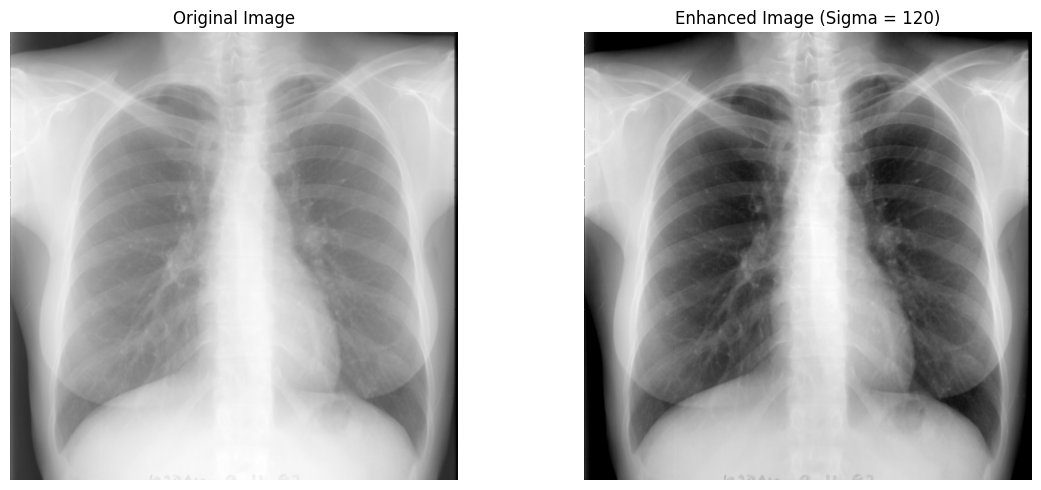

In [10]:
import numpy as np
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
from scipy.io import loadmat
from skimage.measure import shannon_entropy
import os

# 1. تحميل ملف MAT من GitHub (المطلب 1)
url = "https://github.com/ha22756/images/raw/refs/heads/main/JPCNN001_small.mat"
file_name = "JPCNN001_small.mat"

if not os.path.exists(file_name):
    print("جاري تحميل الصورة...")
    os.system(f"wget {url} -O {file_name}")

# 2. استخراج الصورة من ملف الـ MAT
data = loadmat(file_name)
image = data['jrst']['cxr'][0][0]

def local_contrast(image, gauss_std=15):
    """
    هذه الدالة تشرح المطلب رقم 2:
    - طرح المتوسط المحلي (Local Mean Subtraction) لإزالة الإضاءة الخلفية.
    - القسمة على الانحراف المعياري المحلي (Division by Local SD) لتوحيد التباين.
    """
    image = image.astype(np.float64)
    # المطلب 2: طرح المتوسط المحلي
    local_mean = gaussian_filter(image, sigma=gauss_std)
    low_pass = image - local_mean

    # المطلب 2: حساب الانحراف المعياري المحلي للقسمة عليه
    variance = gaussian_filter(low_pass ** 2, sigma=gauss_std)
    std_dev = np.sqrt(variance)
    std_dev[std_dev == 0] = np.mean(std_dev[std_dev != 0]) # لتجنب القسمة على صفر

    # تحسين التباين (LCE)
    enhanced_image = 64 * (low_pass / std_dev) + 127
    enhanced_image = np.clip(enhanced_image, 0, 255)
    return enhanced_image.astype(np.uint8)

# 3. اختبار 5 قيم مختلفة (المطلب 3)
sigmas = [5, 15, 30, 60, 120]

# تجهيز جدول لطباعة النتائج الرقمية (المطلب 6 و 9)
print(f"{'Sigma':<10} | {'Std Dev (Contrast)':<20} | {'Entropy':<10}")
print("-" * 50)

for s in sigmas:
    # تطبيق التحسين
    enhanced = local_contrast(image, gauss_std=s)

    # المطلب 6: حساب مقياسين للصورة (Standard Deviation و Entropy)
    s_val = np.std(enhanced) # يعبر عن التباين (Contrast)
    e_val = shannon_entropy(enhanced) # يعبر عن كمية المعلومات

    print(f"{s:<10} | {s_val:<20.2f} | {e_val:<10.2f}")

    # المطلب 4 و 5: عرض الصورة الأصلية والمحسنة جنب بعض لكل تجربة
    plt.figure(figsize=(12, 5))

    # عرض الصورة الأصلية
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(image, cmap='gray')
    plt.axis('off')

    # عرض الصورة المحسنة بناءً على قيمة Sigma الحالية
    plt.subplot(1, 2, 2)
    plt.title(f"Enhanced Image (Sigma = {s})")
    plt.imshow(enhanced, cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()